# Agentic AI Fundamentals

## Notebook 08: Agentic RAG: Retrieval as a Tool

Retrieval-Augmented Generation grounds a model response in information supplied at runtime. In a conventional RAG workflow, every question follows the same route: retrieve documents and then generate an answer. Agentic RAG makes retrieval one available action, allowing the model to decide whether external knowledge is needed and, if necessary, refine its search after observing the results.

That flexibility creates new failure modes. The model may skip retrieval when it is required, search with a weak query, or answer beyond the retrieved evidence. This notebook therefore treats retrieval quality, source identity, and trajectory inspection as first-class concerns.

## Learning objectives

By the end of this notebook, you should be able to:

- distinguish fixed RAG from agentic RAG;
- split documents into retrievable chunks with stable source IDs;
- build a small TF–IDF vector index;
- return ranked chunks with similarity scores;
- measure retrieval recall on a labeled test set;
- expose retrieval as a validated tool; and
- run a Gemini agent that retrieves only when it judges retrieval necessary.

TF–IDF keeps the notebook fast and transparent. A production system can replace the retrieval backend with embeddings, hybrid search, or reranking without changing the agent-tool boundary.

## 1. Install dependencies and configure Gemini

The retrieval pipeline runs locally. Only the live agent section requires `GEMINI_API_KEY` in Colab Secrets.

In [1]:
%pip install -q -U "google-genai>=1.0.0" "pydantic>=2.7,<3" "scikit-learn>=1.4,<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 19.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.1 which is incompatible.


In [2]:
import os


def load_gemini_api_key() -> str:
    try:
        from google.colab import userdata

        api_key = userdata.get("GEMINI_API_KEY")
    except (ImportError, KeyError):
        api_key = os.getenv("GEMINI_API_KEY")

    if not api_key:
        raise RuntimeError("Add GEMINI_API_KEY to Colab Secrets.")

    return api_key


GEMINI_API_KEY = load_gemini_api_key()

In [3]:
import json
import re
from dataclasses import asdict, dataclass
from typing import Any

from pydantic import BaseModel, ConfigDict, Field, ValidationError
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


MODEL_NAME = "gemini-3.8-flash"
print("Configured model:", MODEL_NAME)

Configured model: gemini-3.8-flash


In [4]:
from google import genai


client = genai.Client(api_key=GEMINI_API_KEY)
print("Gemini client initialized.")

Gemini client initialized.


## 2. Fixed RAG and agentic RAG

A fixed RAG workflow always retrieves before generation:

```text
question → retrieve → generate answer
```

An agentic design exposes retrieval as one possible action:

```text
question → decide → retrieve or answer
                      ↓
             observe and decide again
```

Fixed RAG is easier to test and guarantees that retrieval occurs. Agentic RAG may avoid unnecessary searches and support query refinement, but its decision policy must also be evaluated.

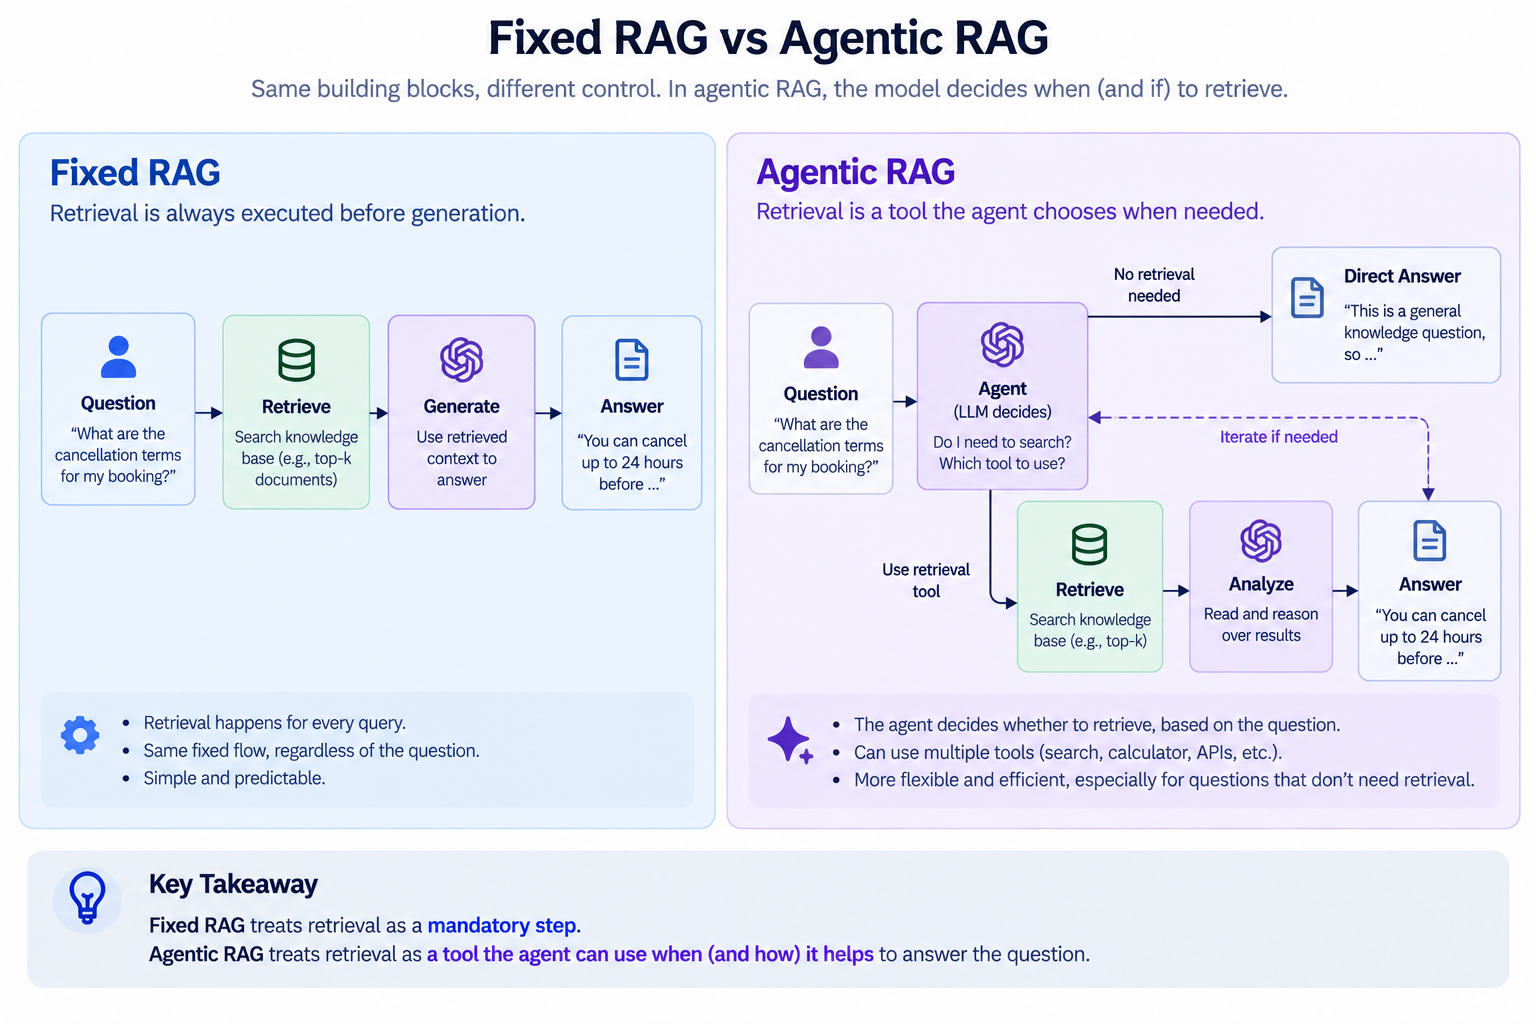

## 3. Create a small source corpus

Each source has a stable ID, title, and text. Stable identity matters because answers should cite evidence and retrieval tests should reference expected sources rather than fragile list positions.

In [5]:
@dataclass(frozen=True)
class SourceDocument:
    source_id: str
    title: str
    text: str


documents = [
    SourceDocument(
        source_id="DOC-AGENT",
        title="Agent Architecture",
        text=(
            "An AI agent places model-driven decisions inside a controlled "
            "execution loop. The surrounding application defines available "
            "tools, validates arguments, records observations, and enforces "
            "termination conditions. An agent is most useful when runtime "
            "evidence must influence which action happens next."
        ),
    ),
    SourceDocument(
        source_id="DOC-RAG",
        title="Retrieval-Augmented Generation",
        text=(
            "Retrieval-Augmented Generation supplies external evidence to a "
            "language model at request time. A retrieval system commonly "
            "chunks documents, indexes the chunks, searches for relevant "
            "passages, and includes those passages in the generation context. "
            "Retrieved evidence should retain source identifiers for citation."
        ),
    ),
    SourceDocument(
        source_id="DOC-GRAPH",
        title="LangGraph State",
        text=(
            "LangGraph models an application as nodes and edges operating on "
            "shared state. Nodes return partial state updates. Conditional "
            "edges select the next node, and checkpointers can preserve state "
            "snapshots associated with a thread identifier."
        ),
    ),
    SourceDocument(
        source_id="DOC-EVAL",
        title="Agent Evaluation",
        text=(
            "Agent evaluation should inspect both final answers and execution "
            "trajectories. Useful measures include task success, tool selection, "
            "argument correctness, retrieval recall, citation support, latency, "
            "token usage, cost, and policy violations."
        ),
    ),
]

print(f"Loaded {len(documents)} source documents.")

Loaded 4 source documents.


## 4. Split sources into chunks

Chunking defines the units returned by retrieval. Very large chunks may contain distracting material, while very small chunks may lose the context needed to interpret a sentence. We will use a word-based splitter with overlap so neighboring chunks share limited context.

In [6]:
@dataclass(frozen=True)
class Chunk:
    chunk_id: str
    source_id: str
    title: str
    text: str


def chunk_document(
    document: SourceDocument,
    chunk_size: int = 35,
    overlap: int = 8,
) -> list[Chunk]:
    if chunk_size < 1:
        raise ValueError("chunk_size must be positive")
    if overlap < 0 or overlap >= chunk_size:
        raise ValueError("overlap must be between 0 and chunk_size - 1")

    words = document.text.split()
    step = chunk_size - overlap
    chunks = []

    for chunk_index, start in enumerate(range(0, len(words), step)):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            break

        chunks.append(
            Chunk(
                chunk_id=f"{document.source_id}-C{chunk_index:02d}",
                source_id=document.source_id,
                title=document.title,
                text=" ".join(chunk_words),
            )
        )

        if start + chunk_size >= len(words):
            break

    return chunks


chunks = [
    chunk
    for document in documents
    for chunk in chunk_document(document)
]

for chunk in chunks:
    print(chunk.chunk_id, "→", chunk.text)

DOC-AGENT-C00 → An AI agent places model-driven decisions inside a controlled execution loop. The surrounding application defines available tools, validates arguments, records observations, and enforces termination conditions. An agent is most useful when runtime evidence must influence
DOC-AGENT-C01 → is most useful when runtime evidence must influence which action happens next.
DOC-RAG-C00 → Retrieval-Augmented Generation supplies external evidence to a language model at request time. A retrieval system commonly chunks documents, indexes the chunks, searches for relevant passages, and includes those passages in the generation context. Retrieved evidence
DOC-RAG-C01 → those passages in the generation context. Retrieved evidence should retain source identifiers for citation.
DOC-GRAPH-C00 → LangGraph models an application as nodes and edges operating on shared state. Nodes return partial state updates. Conditional edges select the next node, and checkpointers can preserve state snapsho

In real projects, chunking should respect document structure such as headings, paragraphs, tables, and code blocks. The best chunking policy depends on the documents and questions, so it should be evaluated rather than chosen by convention alone.

## 5. Build a TF–IDF index

TF–IDF represents each chunk as a sparse vector based on its terms. Cosine similarity compares a query vector with the chunk vectors. Unlike semantic embeddings, TF–IDF mainly relies on lexical overlap, which makes its behavior easy to inspect but weaker for paraphrases.

In [7]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
)

chunk_matrix = vectorizer.fit_transform(chunk.text for chunk in chunks)

print("Index shape:", chunk_matrix.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))

Index shape: (6, 194)
Vocabulary size: 194


## 6. Implement ranked retrieval

The retriever returns structured results containing source identity, chunk text, and similarity score. A minimum score prevents completely unrelated chunks from being returned merely because the caller requested a particular `top_k`.

In [8]:
def search_knowledge_base(
    query: str,
    top_k: int = 3,
    min_score: float = 0.05,
) -> list[dict[str, Any]]:
    if not query.strip():
        raise ValueError("query must not be empty")
    if top_k < 1 or top_k > 5:
        raise ValueError("top_k must be between 1 and 5")

    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, chunk_matrix)[0]
    ranked_indices = scores.argsort()[::-1]
    results = []

    for index in ranked_indices:
        score = float(scores[index])
        if score < min_score:
            continue

        chunk = chunks[index]
        results.append(
            {
                "chunk_id": chunk.chunk_id,
                "source_id": chunk.source_id,
                "title": chunk.title,
                "text": chunk.text,
                "score": round(score, 4),
            }
        )

        if len(results) == top_k:
            break

    return results


example_results = search_knowledge_base(
    "How does LangGraph preserve state snapshots?"
)

for result in example_results:
    print(result)

{'chunk_id': 'DOC-GRAPH-C00', 'source_id': 'DOC-GRAPH', 'title': 'LangGraph State', 'text': 'LangGraph models an application as nodes and edges operating on shared state. Nodes return partial state updates. Conditional edges select the next node, and checkpointers can preserve state snapshots associated with a thread identifier.', 'score': 0.4338}


### 6.1 From TF–IDF to production retrieval

This notebook uses TF–IDF because it makes retrieval behavior easy to inspect. The agent architecture, however, does not depend on TF–IDF. The `retrieve` tool is an interface: its internal search strategy can be replaced without changing the agent loop.

Common alternatives include:

| Approach         | Strength                                                       | Typical use                                 |
| ---------------- | -------------------------------------------------------------- | ------------------------------------------- |
| TF–IDF / BM25    | Strong lexical matching, simple and interpretable              | Keywords, names, exact terminology          |
| Dense embeddings | Captures semantic similarity beyond exact words                | Natural-language knowledge search           |
| Hybrid retrieval | Combines lexical and semantic matching                         | General-purpose production RAG              |
| Reranking        | Reorders retrieved candidates using a stronger relevance model | Improving precision after initial retrieval |

A production pipeline may therefore look like:

```text
User question
     ↓
Agent decides whether retrieval is needed
     ↓
Retrieval tool
     ↓
Candidate retrieval (BM25 / embeddings / hybrid)
     ↓
Optional reranking
     ↓
Evidence returned to the agent
```

These are separate quality problems:

* **Retrieval quality:** Did the system find the relevant evidence?
* **Generation quality:** Did the model use that evidence correctly?
* **Agent decision quality:** Did the agent retrieve when retrieval was necessary, and avoid it when it was not?

A fluent final answer can still come from poor retrieval, and excellent retrieval can still be used incorrectly by the model. For that reason, each layer should be evaluated separately.

The rest of this notebook keeps TF–IDF so that we can focus on the **agent–retrieval interaction** rather than infrastructure.


## 7. Evaluate retrieval before adding generation

A convincing generated answer can hide weak retrieval. We therefore create a small labeled set where each query has one expected source. Recall@k checks whether that source appears among the top results.

In [9]:
retrieval_cases = [
    {
        "query": "What component saves graph state for a thread?",
        "expected_source": "DOC-GRAPH",
    },
    {
        "query": "Which measurements can evaluate an agent trajectory?",
        "expected_source": "DOC-EVAL",
    },
    {
        "query": "Why should retrieved passages keep source identifiers?",
        "expected_source": "DOC-RAG",
    },
    {
        "query": "When is an agent more useful than a fixed workflow?",
        "expected_source": "DOC-AGENT",
    },
]


def evaluate_retrieval(cases: list[dict[str, str]], top_k: int = 2) -> dict[str, Any]:
    records = []

    for case in cases:
        results = search_knowledge_base(case["query"], top_k=top_k)
        retrieved_sources = list(
            dict.fromkeys(result["source_id"] for result in results)
        )
        hit = case["expected_source"] in retrieved_sources

        records.append(
            {
                **case,
                "retrieved_sources": retrieved_sources,
                "hit": hit,
            }
        )

    return {
        "recall_at_k": sum(record["hit"] for record in records) / len(records),
        "top_k": top_k,
        "records": records,
    }


retrieval_report = evaluate_retrieval(retrieval_cases, top_k=2)
print("Recall@2:", retrieval_report["recall_at_k"])
for record in retrieval_report["records"]:
    print(record)

Recall@2: 1.0
{'query': 'What component saves graph state for a thread?', 'expected_source': 'DOC-GRAPH', 'retrieved_sources': ['DOC-GRAPH'], 'hit': True}
{'query': 'Which measurements can evaluate an agent trajectory?', 'expected_source': 'DOC-EVAL', 'retrieved_sources': ['DOC-AGENT', 'DOC-EVAL'], 'hit': True}
{'query': 'Why should retrieved passages keep source identifiers?', 'expected_source': 'DOC-RAG', 'retrieved_sources': ['DOC-RAG'], 'hit': True}
{'query': 'When is an agent more useful than a fixed workflow?', 'expected_source': 'DOC-AGENT', 'retrieved_sources': ['DOC-AGENT'], 'hit': True}


This dataset is intentionally small and should not be presented as a production benchmark. Its purpose is to establish the evaluation pattern before model generation makes errors harder to isolate.

## 8. Expose retrieval as a validated tool

The model receives a schema describing when retrieval is appropriate. Application code still validates the query and executes the local search function.

In [10]:
class SearchKnowledgeBaseArguments(BaseModel):
    model_config = ConfigDict(extra="forbid")

    query: str = Field(
        min_length=3,
        max_length=300,
        description=(
            "A focused search query containing the important technical concepts"
        ),
    )
    top_k: int = Field(default=3, ge=1, le=5)


SEARCH_TOOL_SCHEMA = {
    "type": "function",
    "name": "search_knowledge_base",
    "description": (
        "Search the local Agentic AI knowledge base when the question asks "
        "about course-specific definitions or claims. Do not use for casual "
        "conversation or information already supplied in the user message."
    ),
    "parameters": SearchKnowledgeBaseArguments.model_json_schema(),
}


def execute_search_tool(arguments: dict[str, Any]) -> dict[str, Any]:
    try:
        validated = SearchKnowledgeBaseArguments.model_validate(arguments)
        results = search_knowledge_base(**validated.model_dump())
        return {"success": True, "results": results}
    except ValidationError as error:
        return {
            "success": False,
            "error_type": "invalid_arguments",
            "error": error.errors(),
        }
    except Exception as error:
        return {
            "success": False,
            "error_type": "retrieval_error",
            "error": f"{type(error).__name__}: {error}",
        }


print(json.dumps(SEARCH_TOOL_SCHEMA, indent=2))

{
  "type": "function",
  "name": "search_knowledge_base",
  "description": "Search the local Agentic AI knowledge base when the question asks about course-specific definitions or claims. Do not use for casual conversation or information already supplied in the user message.",
  "parameters": {
    "additionalProperties": false,
    "properties": {
      "query": {
        "description": "A focused search query containing the important technical concepts",
        "maxLength": 300,
        "minLength": 3,
        "title": "Query",
        "type": "string"
      },
      "top_k": {
        "default": 3,
        "maximum": 5,
        "minimum": 1,
        "title": "Top K",
        "type": "integer"
      }
    },
    "required": [
      "query"
    ],
    "title": "SearchKnowledgeBaseArguments",
    "type": "object"
  }
}


## 9. Build the agentic RAG loop

The instructions require source citations in square brackets whenever the answer depends on retrieved evidence. The loop permits query refinement because Gemini can request retrieval again after seeing weak or empty results.

In [11]:
AGENT_INSTRUCTIONS = (
    "You are an assistant for an Agentic AI tutorial. Use the "
    "search_knowledge_base tool when a question depends on the local course "
    "material. You may answer general conversational questions directly. "
    "Base course-specific claims only on retrieved evidence and cite each "
    "supporting source using its source_id in square brackets, for example "
    "[DOC-RAG]. If retrieval returns no adequate evidence, say that the "
    "knowledge base does not contain enough information."
)


def run_rag_agent(
    question: str,
    max_model_turns: int = 4,
) -> dict[str, Any]:
    trace = [{"event": "user_question", "content": question}]
    first_input = AGENT_INSTRUCTIONS + "\n\nUser question:\n" + question

    interaction = client.interactions.create(
        model=MODEL_NAME,
        input=first_input,
        tools=[SEARCH_TOOL_SCHEMA],
    )

    for turn in range(1, max_model_turns + 1):
        calls = [
            step for step in interaction.steps
            if step.type == "function_call"
        ]

        trace.append(
            {
                "event": "model_response",
                "turn": turn,
                "step_types": [step.type for step in interaction.steps],
                "retrieval_calls": len(calls),
            }
        )

        if not calls:
            return {
                "status": "completed" if interaction.output_text else "failed",
                "answer": interaction.output_text,
                "model_turns": turn,
                "trace": trace,
            }

        function_results = []

        for call in calls:
            if call.name != "search_knowledge_base":
                observation = {
                    "success": False,
                    "error": f"Unknown tool: {call.name}",
                }
            else:
                observation = execute_search_tool(dict(call.arguments))

            trace.append(
                {
                    "event": "retrieval",
                    "turn": turn,
                    "query": dict(call.arguments).get("query"),
                    "observation": observation,
                }
            )

            function_results.append(
                {
                    "type": "function_result",
                    "name": call.name,
                    "call_id": call.id,
                    "result": [
                        {
                            "type": "text",
                            "text": json.dumps(observation),
                        }
                    ],
                }
            )

        if turn == max_model_turns:
            break

        interaction = client.interactions.create(
            model=MODEL_NAME,
            previous_interaction_id=interaction.id,
            input=function_results,
            tools=[SEARCH_TOOL_SCHEMA],
        )

    trace.append({"event": "stop", "reason": "maximum_model_turns_reached"})
    return {
        "status": "stopped",
        "answer": None,
        "model_turns": max_model_turns,
        "trace": trace,
    }

## 10. Test a question that requires retrieval

This answer should retrieve from the evaluation source and cite `[DOC-EVAL]`.

In [12]:
grounded_run = run_rag_agent(
    "According to the course material, which measures should be used to evaluate an agent?"
)

print(grounded_run["answer"])
print(json.dumps(grounded_run["trace"], indent=2))

According to the course material, agent evaluation should inspect both final answers and execution trajectories [DOC-EVAL]. Useful measures include:

* **Task success** [DOC-EVAL]
* **Tool selection** [DOC-EVAL]
* **Argument correctness** [DOC-EVAL]
* **Retrieval recall** [DOC-EVAL]
* **Citation support** [DOC-EVAL]
* **Latency** [DOC-EVAL]
* **Token usage** [DOC-EVAL]
* **Cost** [DOC-EVAL]
* **Policy violations** [DOC-EVAL]
[
  {
    "event": "user_question",
    "content": "According to the course material, which measures should be used to evaluate an agent?"
  },
  {
    "event": "model_response",
    "turn": 1,
    "step_types": [
      "thought",
      "function_call"
    ],
    "retrieval_calls": 1
  },
  {
    "event": "retrieval",
    "turn": 1,
    "query": "evaluate an agent measures metrics",
    "observation": {
      "success": true,
      "results": [
        {
          "chunk_id": "DOC-EVAL-C00",
          "source_id": "DOC-EVAL",
          "title": "Agent Evaluation",


## 11. Test a question that may not require retrieval

A greeting has no dependency on the local course material. A sensible agent should normally answer directly and avoid paying the retrieval cost.

In [13]:
direct_run = run_rag_agent("Hello! Briefly introduce yourself.")

print(direct_run["answer"])
print(json.dumps(direct_run["trace"], indent=2))

Hello! I am your assistant for this Agentic AI tutorial. I'm here to help you navigate and understand the concepts, frameworks, and topics covered in the course material. Feel free to ask any questions you have!
[
  {
    "event": "user_question",
    "content": "Hello! Briefly introduce yourself."
  },
  {
    "event": "model_response",
    "turn": 1,
    "step_types": [
      "thought",
      "model_output"
    ],
    "retrieval_calls": 0
  }
]


## 12. Test an unsupported question

The local corpus contains no information about Kubernetes. The correct behavior is to acknowledge insufficient evidence rather than fabricate a course-specific answer.

In [14]:
unsupported_run = run_rag_agent(
    "According to the local course material, how does Kubernetes schedule pods?"
)

print(unsupported_run["answer"])
print(json.dumps(unsupported_run["trace"], indent=2))

The knowledge base does not contain enough information to answer how Kubernetes schedules pods according to the local course material.
[
  {
    "event": "user_question",
    "content": "According to the local course material, how does Kubernetes schedule pods?"
  },
  {
    "event": "model_response",
    "turn": 1,
    "step_types": [
      "thought",
      "function_call"
    ],
    "retrieval_calls": 1
  },
  {
    "event": "retrieval",
    "turn": 1,
    "query": "how does Kubernetes schedule pods",
    "observation": {
      "success": true,
      "results": []
    }
  },
  {
    "event": "model_response",
    "turn": 2,
    "step_types": [
      "thought",
      "function_call"
    ],
    "retrieval_calls": 1
  },
  {
    "event": "retrieval",
    "turn": 2,
    "query": "Kubernetes",
    "observation": {
      "success": true,
      "results": []
    }
  },
  {
    "event": "model_response",
    "turn": 3,
    "step_types": [
      "thought",
      "model_output"
    ],
    "ret

## 13. Evaluate the agentic retrieval decision

Retrieval quality is only one part of Agentic RAG. We must also check whether the model retrieved when required and avoided retrieval when unnecessary.

In [15]:
def retrieval_queries_from_trace(run: dict[str, Any]) -> list[str]:
    return [
        event["query"]
        for event in run["trace"]
        if event["event"] == "retrieval"
    ]


def used_retrieval(run: dict[str, Any]) -> bool:
    return bool(retrieval_queries_from_trace(run))

In [17]:
print("Grounded question retrieved  :", used_retrieval(grounded_run))
print("Greeting retrieved           :", used_retrieval(direct_run))
print("Unsupported question searched:", used_retrieval(unsupported_run))

Grounded question retrieved  : True
Greeting retrieved           : False
Unsupported question searched: True


A larger evaluation set should label whether retrieval is expected, which source should be found, whether the final claim is supported, and whether citations refer to actually retrieved sources.

## 14. Exercise: citation consistency

Implement `citation_consistency(run)`. It should extract source IDs in the final answer using the pattern `[DOC-...]`, collect source IDs returned by retrieval observations, and report whether every cited source was actually retrieved.

In [ ]:
def citation_consistency(run: dict[str, Any]) -> dict[str, Any]:
    # Extract cited and retrieved source IDs, then compare them.
    raise NotImplementedError

<details>
<summary><strong>Reveal one possible solution</strong></summary>

```python
def citation_consistency(run: dict[str, Any]) -> dict[str, Any]:
    answer = run.get("answer") or ""
    cited_sources = set(re.findall(r"\[(DOC-[A-Z]+)\]", answer))
    retrieved_sources = set()

    for event in run["trace"]:
        if event["event"] != "retrieval":
            continue

        observation = event["observation"]
        for result in observation.get("results", []):
            retrieved_sources.add(result["source_id"])

    unsupported_citations = cited_sources - retrieved_sources

    return {
        "cited_sources": sorted(cited_sources),
        "retrieved_sources": sorted(retrieved_sources),
        "unsupported_citations": sorted(unsupported_citations),
        "consistent": not unsupported_citations,
    }
```

Citation consistency does not prove that the cited passage supports the claim. That requires a separate faithfulness or entailment check.

</details>

## Notebook summary

We built a complete miniature RAG pipeline: stable sources, overlapping chunks, a TF–IDF index, scored retrieval, and a labeled retrieval evaluation. We then exposed search as a validated tool and connected it to a Gemini agent that can retrieve, refine its query, answer directly, or acknowledge missing evidence.

The next notebook will add guardrails, approval boundaries, and failure recovery. We will distinguish input validation, execution policy, human authorization, bounded retry, and safe termination rather than treating “guardrails” as a single filter.